# Linear Causal Disentanglement via ICA across Environments

We recover a latent linear SCM and its mixing matrix from multi-environment data,
using ICA in place of the precision-matrix decomposition of Squires et al. (2023).

**Model.** In environment $k$, latents follow $Z = A_kZ + \Omega_k^{1/2}\varepsilon$ with
$\mathrm{Cov}(\varepsilon)=I$, and observations are $X = GZ$ with $G\in\mathbb{R}^{p\times d}$
of full column rank. Writing $B_k = \Omega_k^{-1/2}(I-A_k)$ gives $X = GB_k^{-1}\varepsilon$:
each environment is a linear ICA problem with unmixing matrix $U_k = B_kG^{-1}$.

**Why ICA rather than covariance.** Second moments give $\Theta_k = U_k^\top U_k$, which
determines $U_k$ only up to an orthogonal factor; recovering that factor is what the RQ
machinery of Squires et al. is for. Non-Gaussianity determines $U_k$ up to a signed
permutation, which is a far smaller ambiguity, and makes the rank tests unnecessary.

**Two structural facts.**

1. Assumption 1(b), $B_k = B_0 + e_{i_k}c_k^\top$, implies $U_k - U_0$ has exactly one
   non-zero row: row $i_k$.
2. Assumption 2 (perfect interventions) sets $c_k = \lambda_ke_{i_k} - B_0^\top e_{i_k}$,
   so $(B_k)_{i_k,:} = \lambda_k e_{i_k}^\top$ and therefore
   $(U_k)_{i_k,:} = \lambda_k (G^{-1})_{i_k,:}$.

Fact 2 is the crux: **the intervened row of the unmixing matrix is, up to scale, the
corresponding row of $G^{-1}$.** Fact 1 tells us which row that is.

**Algorithm.** Run ICA per environment; align rows; for each row find the environment
where it is the odd one out (that is its intervention target, and the environment left
unassigned is observational); read $(G^{-1})_{i,:}$ off that row; invert to get $G$;
then $B_k = U_kG$ and $A_0 = I - \mathrm{diag}(B_0)^{-1}B_0$.

**Root-node caveat.** For a root $i$, $(B_0)_{i,:}\propto e_i^\top$ already, so an
intervention changes the row's magnitude but not its direction. We therefore fix the ICA
scale by requiring unit-variance sources and compare full rows, not just directions.

In [1]:
# =====================================================================
#  0. IMPORTS, SEED, STYLE
# =====================================================================
import os, random, itertools, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import FastICA

from wasserstein_ica import WassersteinICA

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
PALETTE = {"FastICA": "#0173B2", "OT-ICA": "#D55E00"}

PAPER_RC = {
    "figure.dpi": 120, "savefig.dpi": 400, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "axes.linewidth": 0.7, "lines.linewidth": 1.4,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linewidth": 0.5,
    "legend.frameon": False,
}
print(f"device = {DEV}   |   seed = {SEED}")

device = cpu   |   seed = 42


## 1. Data-generating process

Nodes are ordered so that an edge $j\to i$ implies $j>i$, making $A_0$ strictly upper
triangular. Environment $0$ is observational; environment $k\in\{1,\dots,d\}$ applies a
**perfect** intervention on node $\pi(k)$, zeroing row $\pi(k)$ of $A$ and resampling
$\Omega_{\pi(k)\pi(k)}$ from a disjoint range so that root interventions are detectable
by magnitude.

**Noise regimes.** Squires et al. use only second moments, so the law of $\varepsilon$ is
irrelevant to them. It is decisive for us. We consider:

| Regime | Description |
|---|---|
| `laplace` | all shocks Laplace; the regime where the `logcosh` proxy is well specified |
| `count_int` | Laplace baseline, intervened node's shock becomes Poisson$(\lambda)$ |
| `count_all` | all shocks Poisson with small rates |
| `leak` | as `count_int`, but the intervention also perturbs a neighbour's shock, violating the one-row-edit assumption |

`count_int` is the biologically motivated case: a knockout pushes the targeted gene into
the low-count regime while the rest of the system is unchanged. `leak` exists to
quantify what happens when the model assumption fails.

In [2]:
# =====================================================================
#  1. DGP
# =====================================================================
def normalise_H(H):
    """Assumption 1(c): largest-|.| entry of each row set to 1."""
    Hn = H.copy()
    for i in range(Hn.shape[0]):
        j = int(np.argmax(np.abs(Hn[i])))
        Hn[i] = Hn[i] / Hn[i, j]
    return Hn


def make_G(p, d, seed, max_cond=50.0, margin=1.15):
    """G whose pseudo-inverse satisfies Assumption 1(c) with a stable argmax.

    Two requirements, both enforced after normalisation.

    Conditioning: dividing a row of G^dagger by a small largest-entry can blow up
    the conditioning of the G actually returned, so cond() is checked on the
    normalised matrix rather than the raw draw.

    Margin: the Assumption 1(c) scaling divides each row by its largest-magnitude
    entry. If the two largest entries of a row are within a few percent, ICA noise
    flips which one is selected, and the recovered row becomes (h_{j*}/h_{k*}) times
    the true one. When the runner-up is negative that factor is close to -1, so
    ||Delta H||_F picks up 2||h_i|| -- an artefact of the convention, not a recovery
    error, and one that leaves the recovered graph correct.
    """
    rng = np.random.default_rng(seed + 13)
    while True:
        G = rng.uniform(-2, 2, (p, d))
        if np.linalg.cond(G) > max_cond:
            continue
        H = normalise_H(np.linalg.pinv(G))
        s = np.sort(np.abs(H), axis=1)
        if np.any(s[:, -1] < margin * s[:, -2]):        # ambiguous argmax
            continue
        Gn = np.linalg.pinv(H)
        if np.linalg.cond(Gn) < max_cond:
            return Gn


def make_scm(d, seed, density=0.75, w_lo=0.25, w_hi=1.0):
    rng = np.random.default_rng(seed)
    A0 = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            if rng.random() < density:
                A0[i, j] = rng.uniform(w_lo, w_hi) * rng.choice([-1.0, 1.0])
    Om0 = rng.uniform(2.0, 4.0, d)
    targets = rng.permutation(d)
    return A0, Om0, targets


def env_matrices(A0, Om0, targets, seed):
    rng = np.random.default_rng(seed + 7)
    d = A0.shape[0]
    Bs, tgt = [np.diag(Om0 ** -0.5) @ (np.eye(d) - A0)], [None]
    for i in targets:
        Ak, Omk = A0.copy(), Om0.copy()
        Ak[i, :] = 0.0
        Omk[i] = rng.uniform(6.0, 8.0)         # disjoint from Unif(2,4)
        Bs.append(np.diag(Omk ** -0.5) @ (np.eye(d) - Ak))
        tgt.append(int(i))
    return Bs, tgt


def _std(x):
    return (x - x.mean()) / x.std()


def draw_eps(regime, d, n, rng, target=None, lam=0.5, leak_rho=0.6, pool=None):
    E = np.empty((d, n))
    for i in range(d):
        if regime == "laplace":
            E[i] = _std(rng.laplace(0, 1, n))
        elif regime == "count_all":
            E[i] = _std(rng.poisson(lam + 0.25 * (i % 3), n).astype(float))
        elif regime in ("count_int", "leak"):
            E[i] = (_std(rng.poisson(lam, n).astype(float)) if i == target
                    else _std(rng.laplace(0, 1, n)))
        elif regime == "pbmc":
            s = rng.choice(pool[i], n, replace=True).astype(float)
            if i == target:                    # binomial thinning = knockdown
                s = rng.binomial(s.astype(int), 0.25).astype(float)
            E[i] = _std(s)
        else:
            raise ValueError(regime)

    if regime == "leak" and target is not None and d > 1:
        nb = (target + 1) % d
        E[nb] = _std(np.sqrt(1 - leak_rho ** 2) * E[nb] + leak_rho * E[target])
    return E


def simulate(regime, d, p, n, seed, **kw):
    A0, Om0, order = make_scm(d, seed)
    Bs, tgt = env_matrices(A0, Om0, order, seed)
    G = make_G(p, d, seed)
    rng = np.random.default_rng(seed + 101)
    Xs = [G @ np.linalg.solve(B, draw_eps(regime, d, n, rng, target=tgt[k], **kw))
          for k, B in enumerate(Bs)]
    return Xs, Bs, tgt, G, A0

## 2. ICA solvers and the shared reduction

For $p>d$ the observations lie in the $d$-dimensional column space of $G$, identical
across environments. We therefore compute one **pooled** orthonormal basis $V\in\mathbb{R}^{p\times d}$
from all environments together and work in $\tilde X_k = V^\top X_k$. Writing
$\tilde G = V^\top G$ gives $\tilde U_k = B_k\tilde G^{-1}$, so the reduced problem has
exactly the structure derived above, and $H = G^\dagger = \tilde G^{-1}V^\top$.

Both solvers are required to return **unit-variance sources**, which removes the ICA
scale ambiguity and leaves only a signed permutation. This matters: root-node
interventions are visible only in the row magnitudes.

In [3]:
# =====================================================================
#  2. SOLVERS
# =====================================================================
def pooled_basis(Xs, d):
    """Common orthonormal basis for col(G), estimated from all environments."""
    Xc = np.concatenate([X - X.mean(1, keepdims=True) for X in Xs], axis=1)
    V, _, _ = np.linalg.svd(Xc, full_matrices=False)
    return V[:, :d]


def _unit_var(U, Xc):
    S = U @ Xc
    return U / S.std(1, keepdims=True)


def ot_ica(Xd, seed, n_restarts=16, defl_iter=200, sym_iter=400, lr=0.1, dither=0.05):
    """OT-ICA on reduced data (d, n). Returns U with unit-variance sources."""
    set_seed(seed)
    d = Xd.shape[0]
    Xc = Xd - Xd.mean(1, keepdims=True)
    m = WassersteinICA(torch.tensor(Xc, dtype=torch.float32, device=DEV))
    m.whiten()
    ws = []
    for _ in range(d):
        prev = torch.stack(ws) if ws else None
        w, _s = m.optimize_wasserstein2(prev_components=prev, continuous=True,
                                        max_iter=defl_iter, lr=0.1,
                                        n_restarts=n_restarts, dither_sigma=dither)
        ws.append(w)
    W = m.optimize_symmetric(n_components=d, optimizer="stiefel", init_w=torch.stack(ws),
                             use_sinkhorn=False, max_iter=sym_iter, lr=lr,
                             dither_sigma=dither, batch_size=1024)
    U = (W @ m.W_white).detach().cpu().numpy().astype(np.float64)
    return _unit_var(U, Xc)


def fast_ica(Xd, seed, max_iter=10000, tol=1e-5):
    Xc = Xd - Xd.mean(1, keepdims=True)
    ica = FastICA(n_components=Xd.shape[0], whiten="unit-variance", fun="logcosh",
                  max_iter=max_iter, tol=tol, random_state=seed)
    ica.fit(Xc.T)
    return _unit_var(ica.components_.astype(np.float64), Xc)


SOLVERS = {"OT-ICA": ot_ica, "FastICA": fast_ica}


def amari(W, A):
    P = np.abs(W @ A)
    n = P.shape[0]
    return (np.sum(np.sum(P / P.max(1, keepdims=True), 1) - 1) +
            np.sum(np.sum(P / P.max(0, keepdims=True), 0) - 1)) / (2 * n)

## 3. The disentanglement algorithm

Three steps, none of which involves a rank test.

**Alignment.** ICA returns rows in an arbitrary order per environment. Any two
environments agree on at least $d-2$ rows, so we align by Hungarian assignment on
$|\cos|$ between rows. To avoid an ambiguous pairing of the two mismatched rows we align
in two passes: first to an arbitrary anchor, then to a **row-wise medoid** across
environments. Since row $i$ equals $(B_0)_{i,:}$ in $d$ of the $d+1$ environments, the
medoid recovers $B_0$'s rows, after which every environment differs from the consensus
in at most one row and the assignment is unambiguous.

**Target and observational identification.** With rows aligned, let $\delta_{ik}$ be the
distance from row $i$ of $\hat U_k$ to the consensus. Assigning rows to environments so
as to maximise $\sum_i\delta_{i,k_i}$ (rectangular Hungarian) gives each node's
intervening environment; the one environment left unassigned is observational.

**Parameter recovery.** $\hat H_{i,:}\propto(\hat U_{k_i})_{i,:}$, rescaled by
Assumption 1(c) — largest-magnitude entry of each row set to $1$, leftmost positive on
ties. Then $\hat G=\hat H^\dagger$, $\hat B_k = \hat U_k\hat G$, and
$\hat A_0 = I - \mathrm{diag}(\hat B_0)^{-1}\hat B_0$, in which the unknown row scaling
of $\hat B_0$ cancels.

In [4]:
# =====================================================================
#  3. DISENTANGLEMENT
# =====================================================================
def _rownorm(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)


def align_to(ref, U, eps=1e-12):
    """Permute and sign-align rows of U to ref.

    The cost is -log(1 - |cos|) rather than |cos|: under Assumption 1(b) all but
    one row of U match ref exactly, and this transform makes those exact matches
    dominate the assignment, so the intervened row is placed by elimination.
    Maximising sum|cos| instead lets a pair of correlated rows outscore the
    correct permutation, which silently corrupts H.
    """
    C = _rownorm(ref) @ _rownorm(U).T
    A = np.abs(C)
    score = -np.log(np.clip(1.0 - A, eps, None))
    r, c = linear_sum_assignment(-score)
    s = np.sign(C[r, c]); s[s == 0] = 1.0
    return U[c] * s[:, None]


def consensus(Us):
    d = Us[0].shape[0]
    out = np.empty_like(Us[0])
    for i in range(d):
        V = np.stack([U[i] for U in Us])
        V = V * np.sign(V @ V[0])[:, None]
        D = np.linalg.norm(V[:, None, :] - V[None, :, :], axis=-1)
        out[i] = V[int(np.argmin(D.sum(1)))]
    return out


def from_unmixing(Us_raw, V, d):
    """Downstream algorithm, shared by the estimated and oracle paths."""
    Us = [align_to(Us_raw[0], U) for U in Us_raw]
    Cn = consensus(Us)
    Us = [align_to(Cn, U) for U in Us]
    Cn = consensus(Us)

    delta = np.stack([[np.linalg.norm(U[i] - Cn[i]) for U in Us] for i in range(d)])
    rows, envs = linear_sum_assignment(-delta)
    tgt_hat = {int(k): int(i) for i, k in zip(rows, envs)}
    obs_hat = int(next(k for k in range(len(Us)) if k not in tgt_hat))

    H_red = np.stack([Us[envs[i]][i] for i in range(d)])      # rows[i] == i here
    H_hat = normalise_H(H_red @ V.T)
    Gr_hat = np.linalg.inv(H_hat @ V)
    Bs_hat = [U @ Gr_hat for U in Us]

    B0 = Bs_hat[obs_hat]
    A_hat = np.eye(d) - B0 / np.diag(B0)[:, None]
    np.fill_diagonal(A_hat, 0.0)

    # rows changed per environment, relative to that environment's own scale
    scale = np.median(np.linalg.norm(Cn, axis=1))
    n_changed = [(delta[:, k] > 0.15 * scale).sum() for k in range(len(Us))]

    return dict(U=Us, H=H_hat, G=np.linalg.pinv(H_hat), A=A_hat, B=Bs_hat,
                targets=tgt_hat, obs=obs_hat, delta=delta,
                n_changed=n_changed, V=V, Gr=Gr_hat)


def disentangle(Xs, d, solver, seed):
    V = pooled_basis(Xs, d)
    Us_raw = [SOLVERS[solver](V.T @ X, seed + 17 * k) for k, X in enumerate(Xs)]
    return from_unmixing(Us_raw, V, d)


def disentangle_oracle(Xs, Bs, G, d):
    """Same pipeline fed the exact unmixing matrices. Must be near-exact."""
    V = pooled_basis(Xs, d)
    Gr = V.T @ G
    Us = [B @ np.linalg.inv(Gr) for B in Bs]
    return from_unmixing(Us, V, d)

## 4. Metrics

- **$\|\Delta\mathbf{H}\|_F$** — error in the demixing map, both matrices normalised by
  Assumption 1(c). Directly comparable to Fig. 2(a) of Squires et al.
- **Directional error** — $\frac{1}{d}\sum_i(1-|\cos\angle(\hat{\mathbf{h}}_i,\mathbf{h}_i)|)$,
  invariant to row scale and sign. The Assumption 1(c) normalisation divides each row
  by its largest-magnitude entry, so a near-tie between the two largest entries lets ICA
  noise flip the choice and rescale the row by $h_{j^*}/h_{k^*}$. That rescaling does not
  change the recovered graph, since the support test cancels it, but it inflates
  $\|\Delta\mathbf{H}\|_F$ by up to $2\|\mathbf{h}_i\|$. We report both and treat the
  directional error as primary.
- **Target accuracy** — fraction of environments whose intervention target is correctly
  identified, plus whether the observational environment is found.
- **Graph recovery** — precision, recall, F1 and SHD on $\mathrm{supp}(A_0)$ at threshold
  $0.1$ (true non-zero weights are $\geq0.25$ by construction).
- **Amari error** — quality of the ICA step itself, averaged over environments. This is the
  quantity the rest of the pipeline inherits.
- **Rows changed per environment** — should be $1$ under Assumption 1(b); larger values
  indicate the one-row-edit assumption is violated.

Each environment identifies one latent node, so the intervention targets give a canonical
labelling of the latents and no optimisation over $S(\mathcal{G})$ is required. The
comparison against ground truth still needs the ICA row permutation resolved, which
`latent_perm` does against the observational environment.

In [5]:
# =====================================================================
#  4. METRICS  (resolve the latent relabelling before comparing)
# =====================================================================
def latent_perm(U_hat_obs, U_true_obs):
    """perm[i] = true latent index of aligned row i."""
    C = _rownorm(U_hat_obs) @ _rownorm(U_true_obs).T
    _, c = linear_sum_assignment(-np.abs(C))
    return c


def evaluate(res, Bs, tgt, G, A0, d):
    V = res["V"]
    U0_true = Bs[0] @ np.linalg.inv(V.T @ G)
    perm = latent_perm(res["U"][0], U0_true)       # env 0 is observational by construction

    H_true = normalise_H(np.linalg.pinv(G))
    H_rel = np.zeros_like(res["H"]); H_rel[perm] = res["H"]
    err_H = float(np.linalg.norm(H_rel - H_true))

    # scale- and sign-invariant: immune to Assumption 1(c) argmax flips, which
    # rescale a row without changing its direction or the recovered graph
    cos_i = np.abs(np.sum(_rownorm(H_rel) * _rownorm(H_true), axis=1))
    err_H_dir = float(np.mean(1.0 - cos_i))

    A_rel = np.zeros((d, d)); A_rel[np.ix_(perm, perm)] = res["A"]

    obs_ok = int(res["obs"] == 0)
    tgt_ok = np.mean([perm[res["targets"][k]] == tgt[k] if k in res["targets"] else False
                      for k in range(1, len(Bs))])

    P = (np.abs(A_rel) > 0.1).astype(int)
    T = (np.abs(A0) > 1e-9).astype(int)
    tp = int((P & T).sum()); fp = int((P & ~T).sum()); fn = int((~P & T).sum())
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)

    am = np.mean([amari(res["U"][k], (V.T @ G) @ np.linalg.inv(Bs[k]))
                  for k in range(len(Bs))])

    return dict(err_H=err_H, err_H_dir=err_H_dir,
                err_A=float(np.linalg.norm(A_rel - A0)),
                obs_ok=obs_ok, tgt_acc=float(tgt_ok),
                precision=prec, recall=rec, f1=f1, shd=fp + fn, amari=am,
                rows_changed=float(np.mean(res["n_changed"][1:])),
                obs_rows_changed=float(res["n_changed"][0]))


def run_once(regime, d, p, n, seed, solver, **kw):
    Xs, Bs, tgt, G, A0 = simulate(regime, d, p, n, seed, **kw)
    res = disentangle(Xs, d, solver, seed)
    m = evaluate(res, Bs, tgt, G, A0, d)
    m.update(regime=regime, d=d, n=n, seed=seed, method=solver)
    return m

In [6]:
# =====================================================================
#  ORACLE TEST: feed the pipeline exact unmixing matrices.
#  Anything other than near-exact recovery means the ALGORITHM is wrong,
#  not the ICA. This is what licenses attributing all later error to the solver.
# =====================================================================
D, P, N = 4, 8, 20_000
N_ORACLE = 20

bad = []
print(f"{'seed':>5} {'err_H':>10} {'dir':>10} {'tgt':>6} {'obs':>5} {'F1':>6} {'rows':>6}")
for s in range(SEED, SEED + N_ORACLE):
    Xs, Bs, tgt, G, A0 = simulate("laplace", D, P, N, s)
    m = evaluate(disentangle_oracle(Xs, Bs, G, D), Bs, tgt, G, A0, D)
    if s < SEED + 5:
        print(f"{s:>5} {m['err_H']:>10.2e} {m['err_H_dir']:>10.2e} "
              f"{m['tgt_acc']:>6.2f} {m['obs_ok']:>5d} {m['f1']:>6.2f} "
              f"{m['rows_changed']:>6.2f}")
    if m["err_H"] > 1e-8 or m["tgt_acc"] < 1.0 or m["f1"] < 1.0:
        bad.append((s, round(m["err_H"], 6), m["tgt_acc"], m["f1"]))

print(f"\nfailures over {N_ORACLE} seeds:",
      bad if bad else "none — oracle exact throughout")

# delta should have one large entry per column, and a near-zero observational column
Xs, Bs, tgt, G, A0 = simulate("laplace", D, P, N, SEED)
res = disentangle_oracle(Xs, Bs, G, D)
print("\ndelta (rows = latents, cols = environments; col 0 is observational):")
print(np.round(res["delta"], 3))
print("true targets :", tgt[1:])
print("est. targets :", res["targets"], "  est. observational:", res["obs"])

 seed      err_H        dir    tgt   obs     F1   rows
   42   3.64e-15   2.78e-17   1.00     1   1.00   1.00
   43   5.60e-15   8.33e-17   1.00     1   1.00   1.00
   44   4.90e-15   5.55e-17   1.00     1   1.00   1.00
   45   7.82e-15  -2.78e-17   1.00     1   1.00   1.00
   46   3.02e-15  -5.55e-17   1.00     1   1.00   1.00

failures over 20 seeds: none — oracle exact throughout

delta (rows = latents, cols = environments; col 0 is observational):
[[0.    0.    0.793 0.    0.   ]
 [0.    0.213 0.    0.    0.   ]
 [0.    0.    0.    0.487 0.   ]
 [0.    0.    0.    0.    0.397]]
true targets : [1, 0, 2, 3]
est. targets : {2: 0, 1: 1, 3: 2, 4: 3}   est. observational: 0


In [7]:
# =====================================================================
#  5. SMOKE TEST  (run this before the sweep)
# =====================================================================
D, P, N = 4, 8, 20_000
for reg in ["laplace", "count_int", "count_all"]:
    line = [f"{reg:<11s}"]
    for sol in ["OT-ICA", "FastICA"]:
        m = run_once(reg, D, P, N, SEED, sol)
        line.append(f"{sol} err_H {m['err_H']:6.3f}  tgt {m['tgt_acc']:.2f}  "
                    f"F1 {m['f1']:.2f}  Amari {m['amari']:.4f}")
    print("   |   ".join(line))

laplace       |   OT-ICA err_H  0.075  tgt 1.00  F1 1.00  Amari 0.0196   |   FastICA err_H  0.066  tgt 1.00  F1 1.00  Amari 0.0207
count_int     |   OT-ICA err_H  0.003  tgt 1.00  F1 1.00  Amari 0.0142   |   FastICA err_H  0.164  tgt 1.00  F1 1.00  Amari 0.0254
count_all     |   OT-ICA err_H  0.023  tgt 1.00  F1 1.00  Amari 0.0077   |   FastICA err_H  6.026  tgt 0.25  F1 0.46  Amari 0.8129


In [8]:
# =====================================================================
#  6. SWEEP OVER REGIMES AND SEEDS
# =====================================================================
import time

REGIMES = ["laplace", "count_int", "count_all", "leak"]
D, P, N, N_SEEDS = 4, 8, 20_000, 10
SEEDS = [SEED + i for i in range(N_SEEDS)]
METRICS = ["amari", "err_H", "err_H_dir", "tgt_acc", "f1", "shd", "rows_changed"]

rows, t0 = [], time.time()
for reg in REGIMES:
    for s in SEEDS:
        for sol in ["OT-ICA", "FastICA"]:
            rows.append(run_once(reg, D, P, N, s, sol))
    print(f"  {reg:<11s} done   {(time.time()-t0)/60:5.1f} min")

res = pd.DataFrame(rows)
res.to_csv("disentanglement_sweep.csv", index=False)

print("\n=== mean (s.d.) over %d seeds, d=%d, p=%d, n=%d ===" % (N_SEEDS, D, P, N))
print(res.groupby(["regime", "method"])[METRICS].agg(["mean", "std"]).round(4).to_string())

# convention flips: large err_H with a correct graph is an argmax tie, not a failure
flip = res[(res.err_H > 0.5) & (res.f1 > 0.95)]
print(f"\nrows with err_H > 0.5 but F1 > 0.95 (Assumption 1(c) flips): {len(flip)}")
if len(flip):
    print(flip[["regime", "method", "seed", "err_H", "err_H_dir", "f1"]]
          .round(4).to_string(index=False))

  laplace     done     3.6 min
  count_int   done     7.7 min
  count_all   done    12.4 min
  leak        done    16.4 min

=== mean (s.d.) over 10 seeds, d=4, p=8, n=20000 ===
                    amari           err_H         err_H_dir         tgt_acc              f1          shd         rows_changed        
                     mean     std    mean     std      mean     std    mean     std    mean     std mean     std         mean     std
regime    method                                                                                                                     
count_all FastICA  0.8354  0.1509  3.3995  1.3079    0.2995  0.1649   0.475  0.3623  0.4862  0.0971  7.7  1.2517        3.175  0.1687
          OT-ICA   0.0083  0.0010  0.0309  0.0092    0.0001  0.0000   1.000  0.0000  1.0000  0.0000  0.0  0.0000        1.000  0.0000
count_int FastICA  0.0236  0.0030  0.1247  0.0393    0.0008  0.0005   1.000  0.0000  1.0000  0.0000  0.0  0.0000        1.000  0.0000
          OT-ICA  

In [ ]:
# =====================================================================
#  6b. SIGN TEST: OT-ICA vs FastICA, paired by seed (Table 6 supp / Table 2 main)
#      `res` already carries an explicit `seed` column, so pairing is direct
#      (no reconstruction needed, unlike the ablation notebooks).
# =====================================================================
from scipy.stats import binomtest

def sign_test_paired(df, group_col, group_vals, metric, ref="OT-ICA", other="FastICA",
                     lower_is_better=True, id_col="seed", method_col="method"):
    rows = []
    for g in group_vals:
        sub = df[df[group_col] == g]
        piv = sub.pivot(index=id_col, columns=method_col, values=metric)
        if ref not in piv.columns or other not in piv.columns:
            continue
        a, b = piv[ref], piv[other]
        mask = a.notna() & b.notna() & (a != b)
        n = int(mask.sum())
        if lower_is_better:
            wins = int((a[mask] < b[mask]).sum())
        else:
            wins = int((a[mask] > b[mask]).sum())
        p = binomtest(wins, n, 0.5, alternative="two-sided").pvalue if n > 0 else np.nan
        rows.append({group_col: g, "metric": metric, "n_pairs": n,
                     f"wins_{ref}": wins, f"losses_{ref}": n - wins, "p_value": p})
    return pd.DataFrame(rows)

print("Sign test on 'amari' (ICA-step quality), paired by seed, OT-ICA vs FastICA:")
sign_amari = sign_test_paired(res, "regime", REGIMES, "amari")
print(sign_amari.to_string(index=False))

print("\nSign test on 'err_H' (demixing-map error), paired by seed:")
sign_errH = sign_test_paired(res, "regime", REGIMES, "err_H")
print(sign_errH.to_string(index=False))

print("\nNote: target accuracy / F1 / SHD are exactly tied between the two solvers "
      "on most regimes here (both 1.00/1.00/0.0) -- a sign test on those columns "
      "would show n_pairs=0 (every pair tied) and is not reported; the ICA-step "
      "metrics (amari, err_H) are where the solvers actually differ and are the "
      "metrics tested above.")

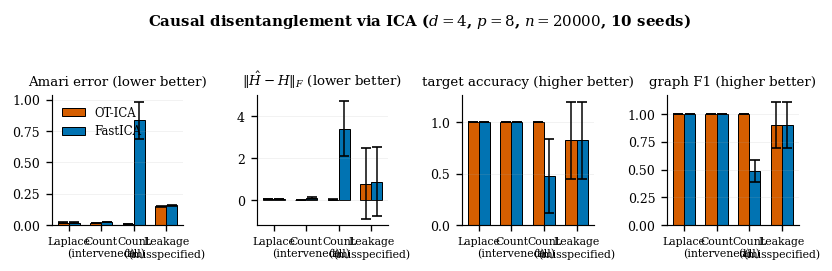

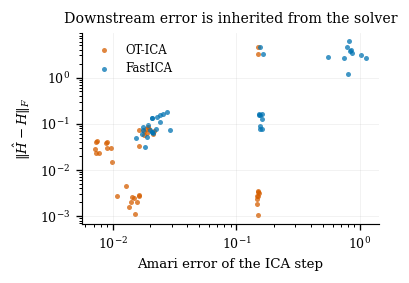

In [9]:
# =====================================================================
#  7. FIGURE: ICA quality propagates to structure recovery
# =====================================================================
LAB = {"laplace": "Laplace", "count_int": "Count\n(intervened)",
       "count_all": "Count\n(all)", "leak": "Leakage\n(misspecified)"}

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 4, figsize=(6.9, 2.1))
    panels = [("amari", "Amari error", "lower"), ("err_H", r"$\|\hat H - H\|_F$", "lower"),
              ("tgt_acc", "target accuracy", "higher"), ("f1", "graph F1", "higher")]
    w, xs = 0.34, np.arange(len(REGIMES))
    for ax, (key, lab, dirn) in zip(axes, panels):
        for off, tag in zip([-w/2, w/2], ["OT-ICA", "FastICA"]):
            g = res[res.method == tag].groupby("regime")[key]
            mu = [g.mean()[r] for r in REGIMES]; sd = [g.std()[r] for r in REGIMES]
            ax.bar(xs + off, mu, w, yerr=sd, color=PALETTE[tag], edgecolor="black",
                   lw=0.6, capsize=3, error_kw=dict(lw=0.9), label=tag)
        ax.set_xticks(xs); ax.set_xticklabels([LAB[r] for r in REGIMES], fontsize=6.5)
        ax.set_title(f"{lab} ({dirn} better)", fontsize=8)
        ax.grid(axis="x", visible=False)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Causal disentanglement via ICA ($d={D}$, $p={P}$, $n={N}$, "
                 f"{N_SEEDS} seeds)", fontweight="bold", fontsize=9, y=1.04)
    fig.tight_layout(w_pad=1.6)
    fig.savefig("disentanglement_regimes.pdf")
    plt.show()

# scatter: ICA quality -> downstream error
with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(3.3, 2.4))
    for tag in ["OT-ICA", "FastICA"]:
        sub = res[res.method == tag]
        ax.scatter(sub.amari, sub.err_H, s=9, color=PALETTE[tag], alpha=0.75,
                   lw=0, label=tag)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Amari error of the ICA step")
    ax.set_ylabel(r"$\|\hat H - H\|_F$")
    ax.set_title("Downstream error is inherited from the solver", fontsize=8.5)
    ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig("disentanglement_propagation.pdf"); plt.show()

## 8. Semi-synthetic: PBMC 3k count marginals

Exogenous shocks are drawn from the empirical UMI-count distributions of real genes,
resampled independently per gene so that $\varepsilon$ is exactly independent while
retaining real count marginals. Because resampling is independent, the cross-gene
correlation in the original data does not enter the simulation; we report it only for
transparency.

Genes are selected by **Fano factor** $\sigma^2/\mu$, which equals $1$ for a Poisson count
and grows with overdispersion. This is the axis that matters here: real UMI counts are
generally zero-inflated and overdispersed, and their heavy right tails are well within the
`logcosh` proxy's operating range. Genes with Fano close to $1$ are those whose variability
is dominated by technical sampling rather than biological signal, and they fall into the
near-Poisson regime where the proxy's detectability collapses. We therefore run two windows,
near-Poisson and strongly overdispersed, and report both: together they map the boundary of
where a proxy contrast suffices.

An intervention is modelled as **binomial thinning** of the targeted gene's counts, the
standard model for reduced expression, which keeps the shock count-valued. The DAG, $G$ and
the intervention targets are known by construction, so the ground truth is exact and only
the shock marginals are real.

In [13]:
# =====================================================================
#  CONTRAST HELPERS AND MARGINAL DETECTABILITY
#  (mirrors the discrete-analysis notebook; must run before any use)
# =====================================================================
import scipy.stats

def analytical_target(n):
    """Exact per-bin Gaussian mean, matching WassersteinICA."""
    p = np.linspace(0.0, 1.0, n + 1)
    z = scipy.stats.norm.ppf(p)
    phi = scipy.stats.norm.pdf(z)
    phi[0] = phi[-1] = 0.0
    return n * (phi[:-1] - phi[1:])

_zq, _wq = np.polynomial.hermite_e.hermegauss(200)
C_GAUSS = float(np.sum(_wq * np.log(np.cosh(_zq))) / np.sqrt(2 * np.pi))

def w2_sq(y, target):
    return float(np.mean((np.sort(_std(y)) - target) ** 2))

def logcosh_sq(y):
    return float((np.mean(np.log(np.cosh(_std(y)))) - C_GAUSS) ** 2)

def detectability(vec, n=20_000, seed=SEED):
    """(W_2^2, logcosh) for a marginal, resampled to n points."""
    rng = np.random.default_rng(seed)
    s = _std(rng.choice(np.asarray(vec, float), n, replace=True))
    return w2_sq(s, analytical_target(n)), logcosh_sq(s)

LAP_W2, LAP_LC = detectability(np.random.default_rng(0).laplace(0, 1, 200_000))
print(f"E[log cosh N(0,1)] = {C_GAUSS:.6f}")
print(f"Laplace reference: W2^2 = {LAP_W2:.4f}, logcosh = {LAP_LC:.2e}")

E[log cosh N(0,1)] = 0.374567
Laplace reference: W2^2 = 0.0350, logcosh = 1.22e-03


In [14]:
# =====================================================================
#  8. PBMC 3k SEMI-SYNTHETIC
# =====================================================================
def load_pbmc_pool(d, seed=SEED, mean_lo=1.0, mean_hi=20.0,
                   fano_lo=None, fano_hi=None, n_cand=600):
    """Empirical count vectors for d genes, optionally filtered by overdispersion.

    Shocks are resampled independently per gene in draw_eps, so only the marginals
    enter the simulation. The Fano factor sigma^2/mu is 1 for a Poisson count and
    large for an overdispersed one; near-Poisson genes are those whose variability
    is dominated by technical sampling rather than biological signal.
    """
    try:
        import scanpy as sc
        ad = sc.datasets.pbmc3k()
        Xc = ad.X.toarray() if hasattr(ad.X, "toarray") else np.asarray(ad.X)
        names = np.asarray(ad.var_names)
        print(f"PBMC 3k: {Xc.shape[0]} cells x {Xc.shape[1]} genes")
    except Exception as e:
        print(f"scanpy unavailable ({e}); using synthetic Poisson counts")
        rng = np.random.default_rng(seed)
        Xc = rng.poisson(0.5, (2700, 500)).astype(float)
        names = np.array([f"sim{i}" for i in range(500)])

    mu = Xc.mean(0)
    fano = np.divide(Xc.var(0), mu, out=np.full_like(mu, np.inf), where=mu > 0)

    m = (mu > mean_lo) & (mu < mean_hi)
    if fano_lo is not None: m &= fano > fano_lo
    if fano_hi is not None: m &= fano < fano_hi
    keep = np.where(m)[0]
    if len(keep) < d:
        raise RuntimeError(f"only {len(keep)} genes match; widen the window")
    print(f"{len(keep)} genes with mean in [{mean_lo}, {mean_hi}], "
          f"Fano in [{fano_lo}, {fano_hi}]")

    keep = keep[np.argsort(fano[keep])][:n_cand]        # most Poisson-like first
    chosen = [int(g) for g in keep[:d]]

    R = np.abs(np.corrcoef(Xc[:, chosen].T)); np.fill_diagonal(R, 0.0)
    print("genes:", list(names[chosen]))
    print("mean:", np.round(mu[chosen], 2), " Fano:", np.round(fano[chosen], 2),
          f" max |rho|: {R.max():.3f}")
    return [Xc[:, g].astype(float) for g in chosen], list(names[chosen])

In [15]:
# =====================================================================
#  WHICH OVERDISPERSION WINDOW DISCRIMINATES THE CONTRASTS?
#  Cheap (seconds per window) relative to a full sweep; run before committing.
# =====================================================================
for tag, kw in [("near-Poisson",  dict(mean_lo=1.0, mean_hi=20.0, fano_hi=2.0)),
                ("mild overdisp", dict(mean_lo=1.0, mean_hi=20.0,
                                       fano_lo=1.5, fano_hi=4.0)),
                ("overdispersed", dict(mean_lo=1.0, mean_hi=20.0, fano_lo=10.0))]:
    try:
        pool, nm = load_pbmc_pool(D, **kw)
    except RuntimeError as e:
        print(f"{tag}: {e}\n"); continue
    print(f"--- {tag} ---")
    print(f"{'gene':<12}{'W2 rel':>9}{'lc rel':>9}{'ratio':>8}")
    for g, col in zip(nm, pool):
        w2, lc = detectability(col)
        print(f"{g:<12}{w2/LAP_W2:>9.2f}{lc/LAP_LC:>9.3f}"
              f"{(w2/LAP_W2)/(lc/LAP_LC):>8.1f}")
    print()
print("rel = detectability relative to a Laplace source under the same contrast.\n"
      "For reference, synthetic Poisson rates 0.196 (lambda=0.5) and 0.003 (lambda=3.0)\n"
      "under logcosh, against 10.4 and 1.6 under W2^2.")

PBMC 3k: 2700 cells x 32738 genes
15 genes with mean in [1.0, 20.0], Fano in [None, 2.0]
genes: ['NBEAL1', 'TOMM7', 'RPL22', 'RPSAP58']
mean: [1.3  1.81 2.14 1.71]  Fano: [1.28 1.61 1.63 1.66]  max |rho|: 0.345
--- near-Poisson ---
gene           W2 rel   lc rel   ratio
NBEAL1           4.56    0.155    29.3
TOMM7            5.03    1.146     4.4
RPL22            3.46    0.230    15.1
RPSAP58          4.38    0.467     9.4

PBMC 3k: 2700 cells x 32738 genes
112 genes with mean in [1.0, 20.0], Fano in [1.5, 4.0]
genes: ['TOMM7', 'RPL22', 'RPSAP58', 'PPDPF']
mean: [1.81 2.14 1.71 2.04]  Fano: [1.61 1.63 1.66 1.69]  max |rho|: 0.345
--- mild overdisp ---
gene           W2 rel   lc rel   ratio
TOMM7            5.03    1.146     4.4
RPL22            3.46    0.230    15.1
RPSAP58          4.38    0.467     9.4
PPDPF            4.66    1.138     4.1

PBMC 3k: 2700 cells x 32738 genes
21 genes with mean in [1.0, 20.0], Fano in [10.0, None]
genes: ['TMSB10', 'SAT1', 'FCER1G', 'COTL1']
mean: [13

In [16]:
# =====================================================================
#  WHICH EXPRESSION WINDOW DISCRIMINATES THE CONTRASTS?
# =====================================================================
lap_w2, lap_lc = detectability(np.random.default_rng(0).laplace(0, 1, 200_000))

for lo, hi in [(0.15, 1.2), (1.0, 3.0), (2.0, 8.0), (5.0, 20.0), (20.0, 100.0)]:
    try:
        pool, nm = load_pbmc_pool(D, mean_lo=lo, mean_hi=hi)
    except RuntimeError as e:
        print(f"[{lo}, {hi}]  skipped: {e}\n"); continue
    print(f"{'gene':<12}{'mean':>7}{'W2 rel':>9}{'lc rel':>9}{'ratio':>8}")
    for g, col in zip(nm, pool):
        w2, lc = detectability(col)
        print(f"{g:<12}{np.mean(col):>7.2f}{w2/lap_w2:>9.2f}"
              f"{lc/lap_lc:>9.3f}{(w2/lap_w2)/(lc/lap_lc):>8.2f}")
    print()

PBMC 3k: 2700 cells x 32738 genes
1426 genes with mean in [0.15, 1.2], Fano in [None, None]
genes: ['BLOC1S4', 'PDAP1', 'C19orf60', 'MPHOSPH8']
mean: [0.18 0.2  0.33 0.24]  Fano: [0.97 0.99 1.01 1.01]  max |rho|: 0.062
gene           mean   W2 rel   lc rel   ratio
BLOC1S4        0.18    17.88    1.944    9.20
PDAP1          0.20    17.50    2.011    8.70
C19orf60       0.33    12.96    0.445   29.15
MPHOSPH8       0.24    15.92    1.286   12.38

PBMC 3k: 2700 cells x 32738 genes
133 genes with mean in [1.0, 3.0], Fano in [None, None]
genes: ['NBEAL1', 'TOMM7', 'RPL22', 'RPSAP58']
mean: [1.3  1.81 2.14 1.71]  Fano: [1.28 1.61 1.63 1.66]  max |rho|: 0.345
gene           mean   W2 rel   lc rel   ratio
NBEAL1         1.30     4.56    0.155   29.34
TOMM7          1.81     5.03    1.146    4.39
RPL22          2.14     3.46    0.230   15.06
RPSAP58        1.71     4.38    0.467    9.38

PBMC 3k: 2700 cells x 32738 genes
109 genes with mean in [2.0, 8.0], Fano in [None, None]
genes: ['RPL22', 

In [17]:
# =====================================================================
#  PBMC SWEEP ACROSS TWO OVERDISPERSION REGIMES
# =====================================================================
WINDOWS = {
    "near-Poisson":  dict(mean_lo=1.0, mean_hi=20.0, fano_hi=2.0),
    "overdispersed": dict(mean_lo=1.0, mean_hi=20.0, fano_lo=10.0),
}

pb_rows, POOLS, DETECT = [], {}, {}

for tag, kw in WINDOWS.items():
    pool, nm = load_pbmc_pool(D, **kw)
    POOLS[tag] = (pool, nm)

    print(f"  {'gene':<12}{'W2 rel':>9}{'lc rel':>9}{'ratio':>8}")
    DETECT[tag] = []
    for g, col in zip(nm, pool):
        w2, lc = detectability(col)
        DETECT[tag].append((g, w2 / LAP_W2, lc / LAP_LC))
        print(f"  {g:<12}{w2/LAP_W2:>9.2f}{lc/LAP_LC:>9.3f}"
              f"{(w2/LAP_W2)/(lc/LAP_LC):>8.1f}")

    for s in SEEDS:
        for sol in ["OT-ICA", "FastICA"]:
            m = run_once("pbmc", D, P, N, s, sol, pool=pool)
            m["window"] = tag
            pb_rows.append(m)
    print(f"  -> {tag} sweep done\n")

pb = pd.DataFrame(pb_rows)
pb.to_csv("pbmc_windows.csv", index=False)

print("=== PBMC 3k, mean (s.d.) over %d seeds ===" % N_SEEDS)
print(pb.groupby(["window", "method"])[METRICS]
        .agg(["mean", "std"]).round(4).to_string())

flip = pb[(pb.err_H > 0.5) & (pb.f1 > 0.95)]
print(f"\nrows with err_H > 0.5 but F1 > 0.95 (Assumption 1(c) flips): {len(flip)}")
if len(flip):
    print(flip[["window", "method", "seed", "err_H", "err_H_dir", "f1"]]
          .round(4).to_string(index=False))

# ---------------------------- LaTeX ----------------------------
print("\n" + r"\begin{tabular}{llccccc}")
print(r"\toprule")
print(r"Genes & Method & Amari $\downarrow$ & $\|\Delta\mathbf{H}\|_F$ $\downarrow$ "
      r"& dir.\ err.\ $\downarrow$ & target $\uparrow$ & F1 $\uparrow$ \\")
print(r"\midrule")
for tag in WINDOWS:
    for i, sol in enumerate(["OT-ICA", "FastICA"]):
        g = pb[(pb.window == tag) & (pb.method == sol)]
        lead = f"\\multirow{{2}}{{*}}{{{tag}}}" if i == 0 else ""
        print(f"{lead} & {sol} & {g.amari.mean():.3f}\\,({g.amari.std():.3f}) "
              f"& {g.err_H.mean():.3f}\\,({g.err_H.std():.3f}) "
              f"& {g.err_H_dir.mean():.2e} "
              f"& {g.tgt_acc.mean():.2f} & {g.f1.mean():.2f} \\\\")
print(r"\bottomrule" + "\n" + r"\end{tabular}")

PBMC 3k: 2700 cells x 32738 genes
15 genes with mean in [1.0, 20.0], Fano in [None, 2.0]
genes: ['NBEAL1', 'TOMM7', 'RPL22', 'RPSAP58']
mean: [1.3  1.81 2.14 1.71]  Fano: [1.28 1.61 1.63 1.66]  max |rho|: 0.345
  gene           W2 rel   lc rel   ratio
  NBEAL1           4.56    0.155    29.3
  TOMM7            5.03    1.146     4.4
  RPL22            3.46    0.230    15.1
  RPSAP58          4.38    0.467     9.4
  -> near-Poisson sweep done

PBMC 3k: 2700 cells x 32738 genes
21 genes with mean in [1.0, 20.0], Fano in [10.0, None]
genes: ['TMSB10', 'SAT1', 'FCER1G', 'COTL1']
mean: [13.82  2.75  2.04  2.99]  Fano: [10.6  10.81 10.93 11.05]  max |rho|: 0.697
  gene           W2 rel   lc rel   ratio
  TMSB10           9.93    9.779     1.0
  SAT1            15.74   12.595     1.2
  FCER1G          17.55   13.379     1.3
  COTL1           15.58   12.548     1.2
  -> overdispersed sweep done

=== PBMC 3k, mean (s.d.) over 10 seeds ===
                        amari           err_H         err

In [ ]:
# =====================================================================
#  8b. SIGN TEST: OT-ICA vs FastICA on the PBMC 3k semi-synthetic sweep
#      (Table 6 supp, PBMC rows), paired by seed. Reuses sign_test_paired
#      defined in the main-sweep sign-test cell above.
# =====================================================================
print("Sign test on 'amari', paired by seed, PBMC windows:")
sign_pb_amari = sign_test_paired(pb, "window", list(WINDOWS.keys()), "amari")
print(sign_pb_amari.to_string(index=False))

print("\nSign test on 'err_H', paired by seed, PBMC windows:")
sign_pb_errH = sign_test_paired(pb, "window", list(WINDOWS.keys()), "err_H")
print(sign_pb_errH.to_string(index=False))